Importar dataset y librerias

In [1]:
import pandas as pd
import os

#Import the dataset
dataset = os.path.join('..','CTC_processed.csv')
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

data.head(10)

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure,month,day,hour,minute
0,65.0,17.6,24.1,100,55.0,0.0,29.9,1,24,13,12
1,70.0,17.6,22.5,105,54.0,0.0,29.9,1,24,13,17
2,82.0,17.7,17.7,114,53.0,0.0,29.9,1,24,13,27
3,78.0,17.7,27.4,105,53.0,0.0,29.9,1,24,13,32
4,69.0,17.9,27.4,97,52.0,0.0,29.9,1,24,13,37
5,70.0,18.1,14.5,105,51.0,0.0,29.9,1,24,13,52
6,68.0,18.1,22.5,104,51.0,0.0,29.9,1,24,14,2
7,60.0,18.1,17.7,97,52.0,0.0,29.9,1,24,14,10
8,61.0,18.0,19.3,95,52.0,0.0,29.9,1,24,14,15
9,62.0,18.0,20.9,93,52.0,0.0,29.9,1,24,14,20


Separamos las variables predictoras y la variable objetivo. 

In [2]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [3]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo

In [4]:
from xgboost import XGBRegressor 
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'learning_rate': [0.01, 0.1, 0.2], #tasa de aprendizaje
          'n_estimators': [50, 100, 900], #numero de arboles
          'subsample': [0.6, 0.8, 1.0]} #datos para entrenamiento de cada arbol
pruebas = XGBRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 81 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV]

Creamos el modelo y entrenamos. Controlamos el sobreajuste.

In [5]:
from xgboost import XGBRegressor
xgb = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 900, subsample = 0.6) #aplicamos los parametros optimos obtenidos
xgb.fit(X_train, y_train)  #entrenamos el modelo

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Predicción y análisis

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = xgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_ajustado = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("MAE: ", mae) #MAE = Error medio en la prediccion
print("MSE:", mse) #MSE = Error cuadratico medio en la prediccion
print("RMSE:", rmse) #RMSE = Raiz del error cuadratico medio en la prediccion
print("R²:", r2) #R^2 = Coeficiente de determinacion
print("R2 ajustado:", r2_ajustado) #R^2 ajustado, si es parecido al normal indica que no hay overfitting ni variables irrelevantes

MAE:  11.229523372237617
MSE: 1208.1839087893661
RMSE: 34.758939983684286
R²: 0.9514742125030392
R2 ajustado: 0.9514161256135288


Obtener variables más importantes en la predicción

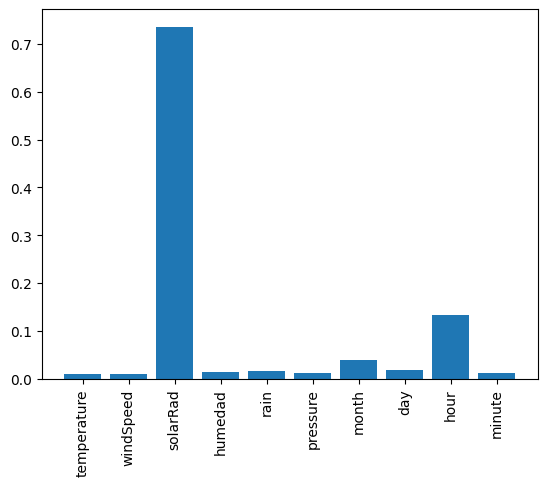

In [7]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()

Comparativa predicción vs realidad

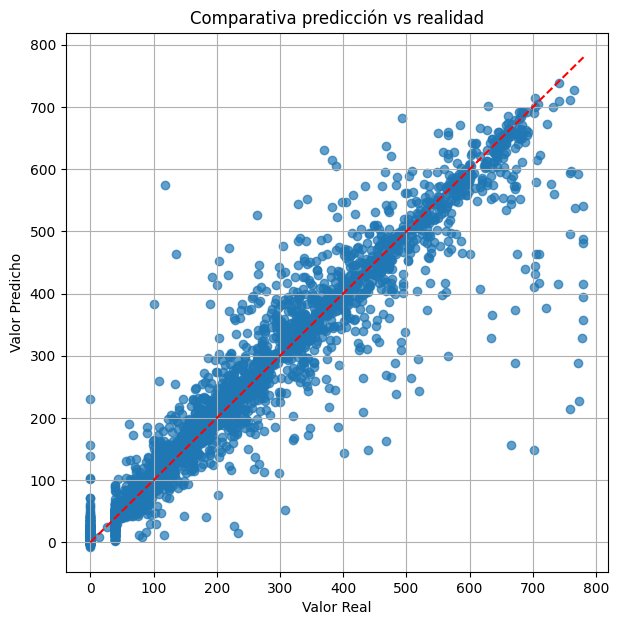

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
